In [30]:
import sqlalchemy
import pymysql
import importlib
from dotenv import load_dotenv
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sqlalchemy import create_engine, text
import pandas as pd
import os
import yaml
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2


project_root = Path.cwd().parent
sys.path.append(str(project_root))
import functions as fn
             
#Data raw folder path:
raw_folder = r"C:\Users\ziden\Desktop\Trainings\RNCP-Project\data\raw"
#Data clean folder path:
clean_folder = r"C:\Users\ziden\Desktop\Trainings\RNCP-Project\data\clean"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
#open qos_df and denormalized_qos
qos_df = fn.open_clean_file("file3")
denormalized_qos = fn.open_clean_file("file6")


C:\Users\ziden\Desktop\Trainings\RNCP-Project\functions.py:7: DtypeWarning: Columns (0: insee_dep) have mixed types. Specify dtype option on import or set low_memory=False.
  from pathlib import Path


,measure_id,operator_id,protocol_id,date_start
total_meausrements,317998.0,NaN,NaN,NaN
nbr_of_operators,NaN,4.0,NaN,NaN
nbr_of_protocols,NaN,NaN,4.0,NaN
start_date,NaN,NaN,NaN,2025-05-26
end_date,NaN,NaN,NaN,2025-09-02


protocol_code
WEB         0.790797
DOWNLOAD    0.104240
STREAM      0.052871
UPLOAD      0.052092
Name: proportion, dtype: float64

protocol_code
WEB         251472
DOWNLOAD     33148
STREAM       16813
UPLOAD       16565
Name: count, dtype: int64

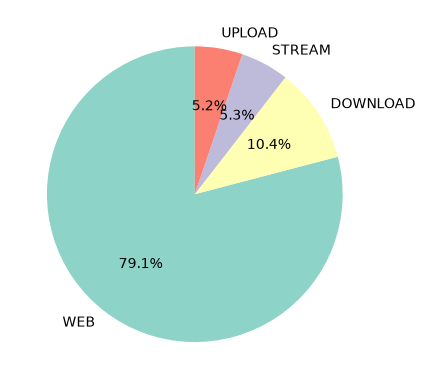

In [32]:
display(denormalized_qos.protocol_code.value_counts(normalize=True))
display(denormalized_qos.protocol_code.value_counts())
denormalized_qos.protocol_code.value_counts(normalize=True).plot.pie(autopct='%.1f%%',startangle=90, colors=sns.color_palette("Set3"))
plt.show()

In [48]:
# Protocol × Operator
protocol_measures_per_operator = denormalized_qos.groupby(["operator_name", "protocol_code"]).agg(number_of_measurements=("measure_id", "count")).reset_index()
protocol_measures_per_operator = protocol_measures_per_operator.sort_values(['operator_name', 'number_of_measurements'], ascending=[False, False])
protocol_measures_per_operator["percentage_within_protocol"] = round(protocol_measures_per_operator["number_of_measurements"]/protocol_measures_per_operator.groupby('protocol_code')['number_of_measurements'].transform("sum")*100,2)

#export table to csv
protocol_measures_per_operator.to_csv(r"C:\Users\ziden\Desktop\Trainings\RNCP-Project\powerbi\input_files\protocol_measures_per_operator.csv", index=False, encoding="utf-8")
protocol_measures_per_operator

,operator_name,protocol_code,number_of_measurements,percentage_within_protocol
15,SFR,WEB,62870,25.00
12,SFR,DOWNLOAD,8276,24.97
13,SFR,STREAM,4200,24.98
14,SFR,UPLOAD,4137,24.97
11,Orange,WEB,62983,25.05
8,Orange,DOWNLOAD,8356,25.21
9,Orange,STREAM,4203,25.00
10,Orange,UPLOAD,4179,25.23
7,Free Mobile,WEB,62979,25.04
4,Free Mobile,DOWNLOAD,8172,24.65


In [54]:
# Performance KPI vs Protocol as defined in the documentation of ARCEP
protocol_kpi = {"WEB" : ["acess_duration", "loaded_in_less_10_secondes", "loaded_in_less_5_secondes", "url"],
                 "STREAM" : ["quality_correct", "quality_perfect"],
                 "DOWNLOAD":["bitrate_dl", "url"],
                 "UPLOAD" : ["bitrate_ul", "url"]
                     }

#protocol_kpi_df = pd.DataFrame(protocol_kpi)
1+1

2

In [63]:
#Compare the number of measurements in different situations between operators

measure_per_situation = denormalized_qos.groupby(["operator_name", "situation"]).agg(nbr_of_measurements=("measure_id","nunique")).reset_index()
measure_per_situation.to_csv(r"C:\Users\ziden\Desktop\Trainings\RNCP-Project\powerbi\input_files\measures_per_situation_per_operator.csv", index=False, encoding="utf-8")

measure_per_situation

,operator_name,situation,nbr_of_measurements
0,Bouygues Telecom,Incar,20868
1,Bouygues Telecom,Indoor,29254
2,Bouygues Telecom,Outdoor,29234
3,Free Mobile,Incar,20980
4,Free Mobile,Indoor,29242
5,Free Mobile,Outdoor,29216
6,Orange,Incar,20987
7,Orange,Indoor,29367
8,Orange,Outdoor,29367
9,SFR,Incar,20941


In [64]:
# Compare Radio conditions in different environments RSRP, RSRQi ndifferent situations Indoor, Outdoor, Incar of the Operators
radio_conditions = denormalized_qos.groupby(["operator_name", "situation"]).agg(mean_rsrp_dbm=("rsrp", "mean"), mean_rsrq_db=("rsrq", "mean"))
radio_conditions = radio_conditions.unstack("situation")
radio_conditions

mean_rsrp_dbm                         mean_rsrq_db  \
situation                Incar      Indoor     Outdoor        Incar   
operator_name                                                         
Bouygues Telecom   -102.174019 -104.369829 -100.952632   -12.070106   
Free Mobile        -103.842700 -106.080610 -103.171680   -12.232697   
Orange             -101.914654 -103.988092 -100.411156   -10.965602   
SFR                -101.499569 -103.554269 -100.562433   -12.144010   

                                        
situation            Indoor    Outdoor  
operator_name                           
Bouygues Telecom -12.586079 -12.025206  
Free Mobile      -12.566828 -12.095961  
Orange           -11.443003 -10.820179  
SFR              -12.503055 -12.075704

In [55]:
qos_df.situation.unique()

<StringArray>
['Incar', 'Indoor', 'Outdoor']
Length: 3, dtype: str